In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F


spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("parquet/run1082_srppac.parquet")
df.show(5)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/01/23 17:45:57 WARN Utils: Your hostname, gpuana02, resolves to a loopback address: 127.0.1.1; using 133.11.152.134 instead (on interface enp4s0)
26/01/23 17:45:57 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/01/23 17:45:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/23 17:45:58 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


+---------+-------------------+-----------+------------------+-----------+-------+
|hbfNumber|           sr_pos_x|   sr_ins_x|          sr_pos_y|   sr_ins_y|runname|
+---------+-------------------+-----------+------------------+-----------+-------+
|  4853703|   -4.9128432482481| 0.18715675|-2.705519573688507|-0.12551957|run1082|
|  4853762| -20.49372604638338|-0.09372605| -9.56399358034134|  0.7560064|run1082|
|  4802858|-1.1203663349151611| -1.1203663| 8.470203151702881| 0.73020315|run1082|
|  4846816|               NULL|       NULL| 16.61708662986755|  1.1370866|run1082|
|  4846898| -22.49053395986557| 0.45946604|-4.038310322761536|  1.1216897|run1082|
+---------+-------------------+-----------+------------------+-----------+-------+
only showing top 5 rows


Statistics:
[[  15. 2352.   19.]
 [  50. 9545.  101.]
 [   0.    0.    0.]]


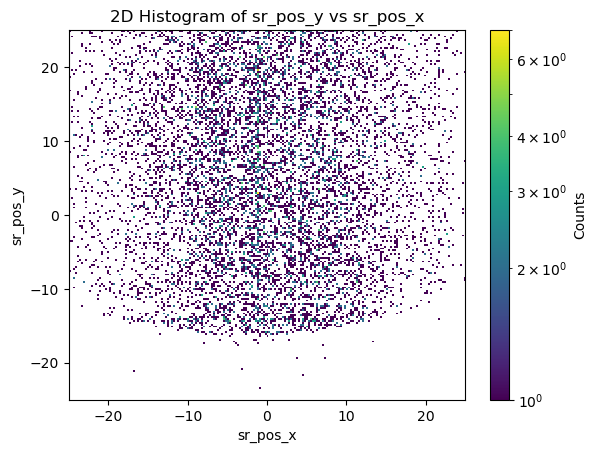

In [2]:
from hist.sparkHist2d import Hist2D
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
h = Hist2D(df, ["sr_pos_x", "sr_pos_y"], [200,200], [[-25,25], [-25,25]], norm=LogNorm(), interpolation='none')
plt.show()